Cell 1 — imports

In [9]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

Cell 2 — image preprocessing

In [10]:
transform = transforms.Compose([
    transforms.Resize((224,224)),     # ResNet input size
    transforms.RandomHorizontalFlip(), # data augmentation
    transforms.ToTensor()
])

Cell 3 — dataset loading

In [11]:
train_dataset = datasets.ImageFolder("data/train", transform=transform)
test_dataset = datasets.ImageFolder("data/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(train_dataset.classes)  # ['house', 'not_house']
print(test_dataset.classes)   # ['house', 'not_house']

['house', 'not_house']
['house', 'not_house']


Cell 4 — load pretrained model

In [12]:
#load pretrained model
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
#modify last layer
model.fc = nn.Linear(num_features, 2)  # 2 classes: house / not_house

/home/marwen/Desktop/WEB_PROJECT/aimicroservice/aivenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/marwen/Desktop/WEB_PROJECT/aimicroservice/aivenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    # tqdm progress bar for this epoch
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, labels in pbar:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        batch_loss = running_loss / len(pbar)
        batch_acc = correct / total

        # Update tqdm postfix
        pbar.set_postfix(Loss=f"{batch_loss:.4f}", Accuracy=f"{batch_acc:.4f}")

    # Epoch summary
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    print(f"Epoch {epoch+1} finished - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

Epoch 1/5: 100%|██████████| 238/238 [12:13<00:00,  3.08s/it, Accuracy=0.9709, Loss=0.0811]


Epoch 1 finished - Loss: 0.0811, Accuracy: 0.9709


Epoch 2/5: 100%|██████████| 238/238 [11:51<00:00,  2.99s/it, Accuracy=0.9826, Loss=0.0585]


Epoch 2 finished - Loss: 0.0585, Accuracy: 0.9826


Epoch 3/5: 100%|██████████| 238/238 [11:40<00:00,  2.95s/it, Accuracy=0.9881, Loss=0.0407]


Epoch 3 finished - Loss: 0.0407, Accuracy: 0.9881


Epoch 4/5: 100%|██████████| 238/238 [11:33<00:00,  2.91s/it, Accuracy=0.9856, Loss=0.0412]


Epoch 4 finished - Loss: 0.0412, Accuracy: 0.9856


Epoch 5/5: 100%|██████████| 238/238 [11:12<00:00,  2.82s/it, Accuracy=0.9914, Loss=0.0258]

Epoch 5 finished - Loss: 0.0258, Accuracy: 0.9914


In [15]:
# Evaluate on test set
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print("Test accuracy:", accuracy)

Test accuracy: 0.9892150988615938


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Accuracy
accuracy = (torch.tensor(all_preds) == torch.tensor(all_labels)).sum().item() / len(all_labels)
print("Test Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Classification report (precision, recall, f1-score per class)
report = classification_report(all_labels, all_preds)
print("Classification Report:\n", report)

# Macro F1, Precision, Recall
f1_macro = f1_score(all_labels, all_preds, average='macro')
precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro = recall_score(all_labels, all_preds, average='macro')

print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")

Test Accuracy: 0.987417615338526
Confusion Matrix:
 [[1396   18]
 [   3  252]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      1414
           1       0.93      0.99      0.96       255

    accuracy                           0.99      1669
   macro avg       0.97      0.99      0.98      1669
weighted avg       0.99      0.99      0.99      1669

F1 Score (Macro): 0.9763
Precision (Macro): 0.9656
Recall (Macro): 0.9878


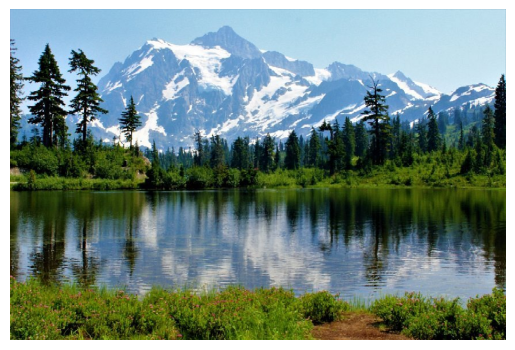

Predicted class index: 1
Predicted class: not_house


In [22]:
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import models, transforms

img_path = Path("picture-lake.jpg")
model_path = Path("house_model.pth")

if not img_path.exists():
    raise FileNotFoundError(f"Image not found: {img_path.resolve()}")

image = Image.open(img_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image_tensor = inference_transform(image).unsqueeze(0)

if "model" not in globals():
    if not model_path.exists():
        raise FileNotFoundError(
            f"Model not found in memory and weights file is missing: {model_path.resolve()}"
        )
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))

model.eval()
with torch.no_grad():
    outputs = model(image_tensor)
    predicted = outputs.argmax(dim=1)

class_names = ["house", "not_house"]
print("Predicted class index:", predicted.item())
print("Predicted class:", class_names[predicted.item()])

In [14]:
#Cell 7 — save trained model
torch.save(model.state_dict(), "house_model.pth")